In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44827,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43771,Total threads: 3
Dashboard: http://127.0.0.1:33319/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:38031,


Task exception was never retrieved
future: <Task finished name='Task-2356344' coro=<Client._gather.<locals>.wait() done, defined at /work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:2377> exception=AllExit()>
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py", line 2386, in wait
    raise AllExit()
distributed.client.AllExit


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
stores1 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678").glob("Parcels_run_*_*.zarr"))
stores2  = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_67891").glob("Parcels_run_*_*.zarr"))
stores3 = sorted(Path("/work/bk1450/b383184/Amazon/Mercator/data/tracks_78876").glob("Parcels_run_*_*.zarr"))

stores = stores1+stores2+stores3
stores[:3]

[PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-11 00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-16 00:00:00.zarr')]

In [5]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

In [6]:
ds = ds.drop_vars(['z','sal','temp'])
ds

<xarray.Dataset> Size: 362GB
Dimensions:     (trajectory: 16280000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 120GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [7]:
num_valid_obs_steps = int(ds.lat.notnull().any('trajectory').sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 290GB
Dimensions:     (trajectory: 16280000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [8]:
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())

In [9]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

In [10]:
# days since each particle's release (start_time already = ds.time.isel(obs=0))
ds = ds.assign(age_days=(ds.time - ds.start_time) / np.timedelta64(1, "D"))
ds

<xarray.Dataset> Size: 386GB
Dimensions:     (trajectory: 16280000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_time  (trajectory) datetime64[ns] 130MB 1993-01-06 ... 2013-08-20
    age_days    (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

## Histogram calculation 5 daily

In [11]:
lat_bins = np.linspace(lat_min, lat_max, 30)
lon_bins = np.linspace(lon_min, lon_max, 80)

In [12]:
def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [12]:
# calc hist for each start year / start month
hist = ds.groupby(["start_time"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist = hist.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
# hist.drop_encoding().compute().to_netcdf("_hist_AT_N_seminar_3.nc")

In [13]:
ds = ds.assign(start_season=ds.start_time.dt.season)
ds

<xarray.Dataset> Size: 290GB
Dimensions:       (trajectory: 16280000, obs: 741)
Coordinates:
  * obs           (obs) int32 3kB 0 1 2 3 4 5 6 ... 734 735 736 737 738 739 740
  * trajectory    (trajectory) int64 130MB 0 1 2 3 4 ... 9996 9997 9998 9999
Data variables:
    lat           (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon           (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time          (trajectory, obs) datetime64[ns] 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_time    (trajectory) datetime64[ns] 130MB 1993-01-06 ... 2013-08-20
    start_season  (trajectory) <U3 195MB 'DJF' 'DJF' 'DJF' ... 'JJA' 'JJA' 'JJA'
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [ ]:
hist_season = ds.groupby(["start_season"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist_season = hist_season.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
# hist_season.drop_encoding().compute().to_netcdf("_hist_Season_N_seminar_3.nc")

## Histogram calculation monthly

In [13]:
ds_m = ds.assign(start_month=ds.start_time.dt.month)
ds_m = ds_m.assign(start_year=ds.start_time.dt.year)
ds_m

<xarray.Dataset> Size: 387GB
Dimensions:      (trajectory: 16280000, obs: 741)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory   (trajectory) int64 130MB 0 1 2 3 4 ... 9995 9996 9997 9998 9999
Data variables:
    lat          (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    lon          (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 130MB 1993-01-06 ... 2013-08-20
    age_days     (trajectory, obs) float64 97GB dask.array<chunksize=(10000, 185), meta=np.ndarray>
    start_month  (trajectory) int64 130MB 1 1 1 1 1 1 1 1 1 ... 8 8 8 8 8 8 8 8
    start_year   (trajectory) int64 130MB 1993 1993 1993 1993 ... 2013 2013 2013
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [30]:
hist_monthly = ds_m.groupby(["start_month","start_year"]).apply(calc_hist)
hist_monthly = hist_monthly.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()
# compute and store to file
# hist_monthly.drop_encoding().compute().to_netcdf("_hist_monthly_year.nc")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 26.31 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
hist_month = ds_m.groupby(["start_month"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist_month = hist_month.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
# hist_month.drop_encoding().compute().to_netcdf("_hist_month.nc")

#### Wet and Dry seasons of river discharge

* OND --> Dry season
* JFM --> Transition
* AMJ --> Wet season
* JAS --> Transition

In [ ]:
months = ds.start_time.dt.month

month_to_season = {
    10: 'OND', 11: 'OND', 12: 'OND',
    1: 'JFM', 2: 'JFM', 3: 'JFM',
    4: 'AMJ', 5: 'AMJ', 6: 'AMJ',
    7: 'JAS', 8: 'JAS', 9: 'JAS',
}

# Map to season labels
season_labels = xr.apply_ufunc(
    np.vectorize(month_to_season.get),
    months,
    dask='parallelized',
    output_dtypes=[object]
)


# Assign as a new coordinate
ds_wd = ds.assign_coords(start_season=('start_time', season_labels.data))

hist_season_wd = ds_wd.groupby(["start_season"]).apply(calc_hist)
hist_season_wd = hist_season_wd.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

hist_season_wd.drop_encoding().compute().to_netcdf("_hist_Season_Wet_Dry_river.nc")
# ds_seasonal = ds.groupby(season_labels).mean('time')
# hist_wd = ds.groupby(["start_season"]).apply(calc_hist)


## Particle age

In [16]:
def calc_age(d):
    count   = xhist(d.lon, d.lat, bins=[lon_bins, lat_bins],
                    dim=["trajectory"], bin_dim_suffix="")
    age_sum = xhist(d.lon, d.lat, bins=[lon_bins, lat_bins],
                    dim=["trajectory"], weights=d.age_days, bin_dim_suffix="")
    return xr.Dataset({"count": count, "age_sum": age_sum})

age_month = ds_m.groupby("start_month").apply(calc_age)
age_month = age_month.isel(obs=slice(1, None)).sum("obs")          # collapse obs (skip release point)

mean_age_month = age_month.age_sum / age_month["count"].where(age_month["count"] > 0)
# mean_age_month.to_netcdf("_mean_age_month.nc")   # optional, like your other saves
mean_age_month


<xarray.DataArray (start_month: 12, lon: 79, lat: 29)> Size: 220kB
dask.array<truediv, shape=(12, 79, 29), dtype=float64, chunksize=(1, 79, 29), chunktype=numpy.ndarray>
Coordinates:
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [18]:
mean_age_month.drop_encoding().compute().to_netcdf("_hist_age_month.nc")

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 146.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [2]:
age_month = xr.open_dataset('_hist_age_month.nc').compute()
age_month

<xarray.Dataset> Size: 221kB
Dimensions:                        (lon: 79, lat: 29, start_month: 12)
Coordinates:
  * lon                            (lon) float64 632B -94.31 -93.0 ... 7.384
  * lat                            (lat) float64 232B -7.067 -5.765 ... 29.37
  * start_month                    (start_month) int64 96B 1 2 3 4 ... 10 11 12
Data variables:
    __xarray_dataarray_variable__  (start_month, lon, lat) float64 220kB nan ...

In [3]:
age_month.__xarray_dataarray_variable__

<xarray.DataArray '__xarray_dataarray_variable__' (start_month: 12, lon: 79,
                                                   lat: 29)> Size: 220kB
array([[[         nan,          nan,          nan, ..., 175.28508772,
                  nan,          nan],
        [         nan,          nan,          nan, ..., 172.35130719,
                  nan,          nan],
        [         nan,          nan,          nan, ..., 167.29457364,
         173.08333333,          nan],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ..., 180.73958333,
                  nan,          nan],
...
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ..., 184.34375   ,
                  nan,          nan],
        [         nan,          nan,          nan, ..., 179.11784512,
         182.76315789,          nan],
        [         nan,          nan,          nan, ..., 176.48884449,
         176.15093848, 184.34375   ],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]]], shape=(12, 79, 29))
Coordinates:
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [ ]:
# sszpalette uses plt.register_cmap, removed in matplotlib >=3.9 -> shim it onto the new API
import matplotlib.pyplot as plt, matplotlib as mpl
if not hasattr(plt, "register_cmap"):
    plt.register_cmap = lambda cmap=None, name=None, **k: mpl.colormaps.register(
        cmap, name=name or cmap.name, force=True)

import sszpalette
colorsmaps = sszpalette.register()
colorsmaps

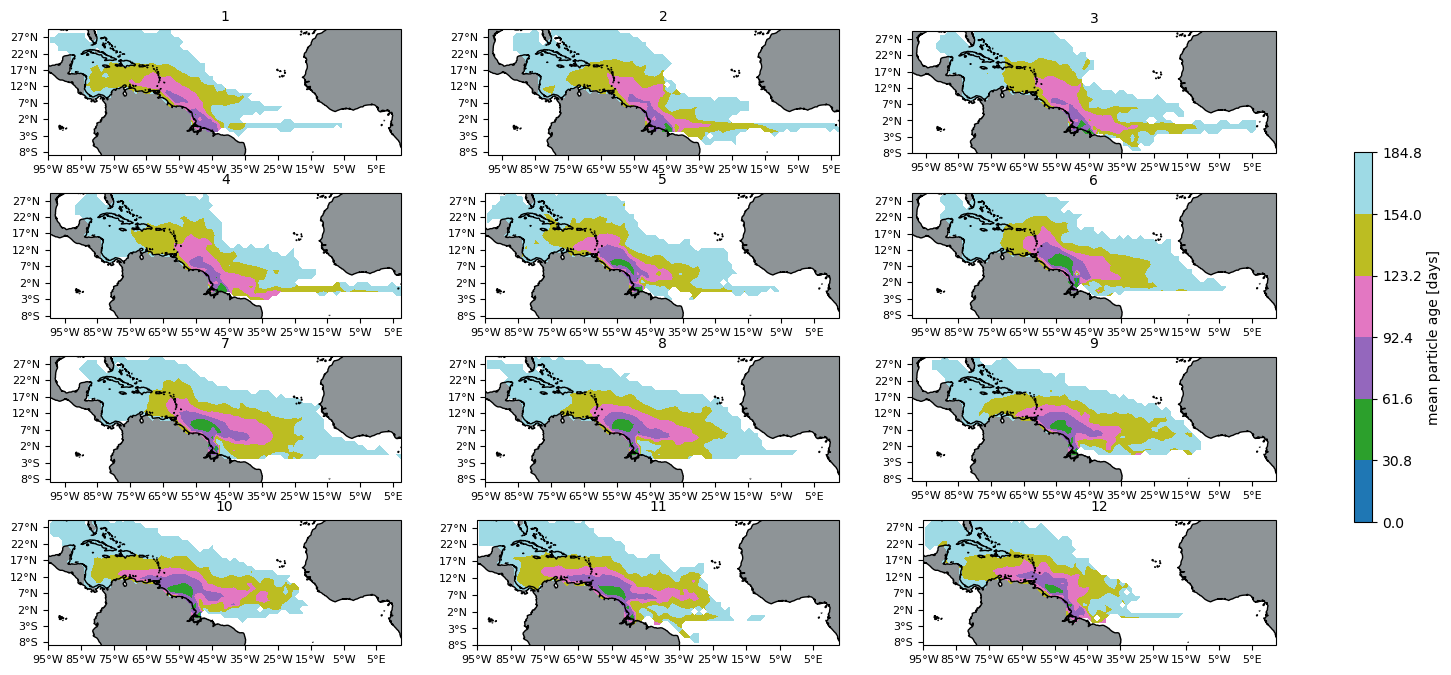

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches


proj = ccrs.PlateCarree()
fig, ax = plt.subplots(4, 3, figsize=(20, 8), subplot_kw=dict(projection=proj))
ax = ax.ravel()

vmax = float(age_month.__xarray_dataarray_variable__.max())
for i in range(12):
    dd = age_month.__xarray_dataarray_variable__.sel(start_month=i + 1)
    pcm = dd.plot.contourf(
        x="lon", y="lat", ax=ax[i], transform=proj,
        cmap="tab20", vmin=0,vmax=vmax, add_colorbar=False,
    )
    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor="#8e9497ff", zorder=0)
    ax[i].set_title(i + 1, fontsize=10)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10), crs=proj)
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5), crs=proj)
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format=".0f", degree_symbol="°"))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format=".0f", degree_symbol="°"))
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel(""); ax[i].set_ylabel("")

fig.subplots_adjust(hspace=0.3)
fig.colorbar(pcm, ax=ax, shrink=0.6, label="mean particle age [days]")
# plt.savefig("time_residence_LPT.png", dpi=300, bbox_inches="tight")
plt.show()


## Plots

### Seasonality

In [21]:
hist_season = xr.open_dataset("_hist_Season_N_seminar_3.nc").compute().histogram_lon_lat
hist_season

<xarray.DataArray 'histogram_lon_lat' (start_season: 4, obs: 37, lon: 79,
                                       lat: 29)> Size: 3MB
array([[[[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
...
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,   148,    14,   557],
         [    0,     0,     0, ...,  1011,   449,   986],
         [    0,     0,     0, ..., 12278,  7735,  1203],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,   201,    65,   730],
         [    0,     0,     0, ...,  1466,  1084,  1402],
         [    0,     0,     0, ..., 11921, 10735,  1384],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]]]],
      shape=(4, 37, 79, 29))
Coordinates:
  * obs           (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon           (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat           (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_season  (start_season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'

In [ ]:
alpha = 0.5  # 0..1

data0 = hist_season.sel(start_season='DJF').sum("obs")
data1 = hist_season.sel(start_season='MAM').sum("obs")
data2 = hist_season.sel(start_season='JJA').sum("obs")
data3 = hist_season.sel(start_season='SON').sum("obs")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

labels_colors = [
    ('DJF', '#000080'),
    ('MAM', '#a0522d'),
    ('JJA', '#afeeee'),
    ('SON', '#ff0000'),
]

def log10_safe(da):
    return da.where(da > 0).pipe(np.log10)

fig, ax = plt.subplots(1, 1, figsize=(10, 20),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))

# Plot layers
layers = [
    (data0, '#000080', 'DJF'),
    (data1, '#a0522d', 'MAM'),
    (data2, '#afeeee', 'JJA'),
    (data3, '#ff0000', 'SON'),
]
for da, color, _ in layers:
    log10_safe(da).plot.contourf(
        x='lon', y='lat', ax=ax, transform=ccrs.PlateCarree(),
        add_colorbar=False, colors=[color], alpha=0.5, levels = [1,hist_season.max()]
    )

# Map cosmetics
ax.set_title('Seasonality')
ax.coastlines(resolution='10m')
ax.add_feature(cf.BORDERS, linewidth=0.5)
ax.add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)

# Ticks + formatters
lon_ticks = np.arange(np.round(hist_season.lon.min().item()),
                      np.round(hist_season.lon.max().item()) + 1e-6, 5)
lat_ticks = np.arange(np.round(hist_season.lat.min().item()),
                      np.round(hist_season.lat.max().item()) + 1e-6, 5)
ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
ax.set_xlabel('')
ax.set_ylabel('')

# Legend (proxy patches)
handles = [mpatches.Patch(color=c, alpha=0.5, label=lab) for _, c, lab in layers]
ax.legend(handles=handles, title='Season', loc='upper right', frameon=True)

plt.tight_layout()
# plt.savefig("seasonality.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# seasons = np.unique(hist_season.start_season)  # expect 4
seasons = ['DJF','MAM','JJA','SON']

fig, ax = plt.subplots(2, 2, figsize=(9, 7),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

for i in range(len(seasons)):
    dd = hist_season.sel(start_season=str(seasons[i])).sum("obs")

    np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
        add_colorbar=False, cmap='Spectral_r'
    )
    ax[i].coastlines()
    ax[i].set_title(seasons[i], fontsize=12)
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    ax[i].tick_params(labelsize=9)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

fig.subplots_adjust(wspace=0.2, hspace=-0.65)
plt.tight_layout()
# plt.savefig("seasonality_subplots_45678.png", dpi=300, bbox_inches="tight")
plt.show()


### Monthly Mean State

In [ ]:
hist_month = xr.open_dataset("_hist_month.nc").compute().histogram_lon_lat
hist_month

In [ ]:
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    3, 4,
    figsize=(20, 8),                      # a bit wider, not so tall
    subplot_kw=dict(projection=proj)
)
ax = ax.ravel()

for i in range(12):
    dd = hist_month.sel(start_month=i+1).sum("obs")

    # plot
    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=proj,
        add_colorbar=False, cmap='Spectral_r'
    )

    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_title(i+1, fontsize=10)

    # ticks & labels
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=proj
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=proj
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Tighter spacing: reduce both wspace and hspace
fig.subplots_adjust(
    left=0.05, right=0.95,
    bottom=0.08, top=0.90,
    wspace=0.15, hspace=0.10
)

# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.ax.set_xlabel('log10(counts)', fontsize=10)

plt.show()

* Dry season (less Amazon discharge): October-November-December --> ARP plume is spread to the Caribbean
* Weat season (More Amazon discharge): May-June-July --> ARP plume is spread to the Tropical Atlantic (Africa) 

### Wet and Dry seasons

Precipitation varied seasonally, with a **wet season from mid-December 2000 to July 2001** characterized by successive rainy days, wet soil, and, relative to the dry season, cooler temperatures, greater cloudiness, and reduced incoming solar and net radiation (Rocha et al., 2004)

The seasonal cycle of the near-surface (~5 m below the sea surface) ocean salinity in the APR from multiple ocean-state estimate products shows the **freshest values in May–June–July** and the saltiest in **December–January–February** (Fig. 1d), which largely follows the seasonal cycle of the Amazon river discharge (Fig. 1c). Although the magnitude of the seasonal cycle varies with the chosen datasets, these ocean-state estimate datasets agree that the APR ocean salinity exhibits a similar seasonal evolution to the Amazon river discharge with no apparent lag

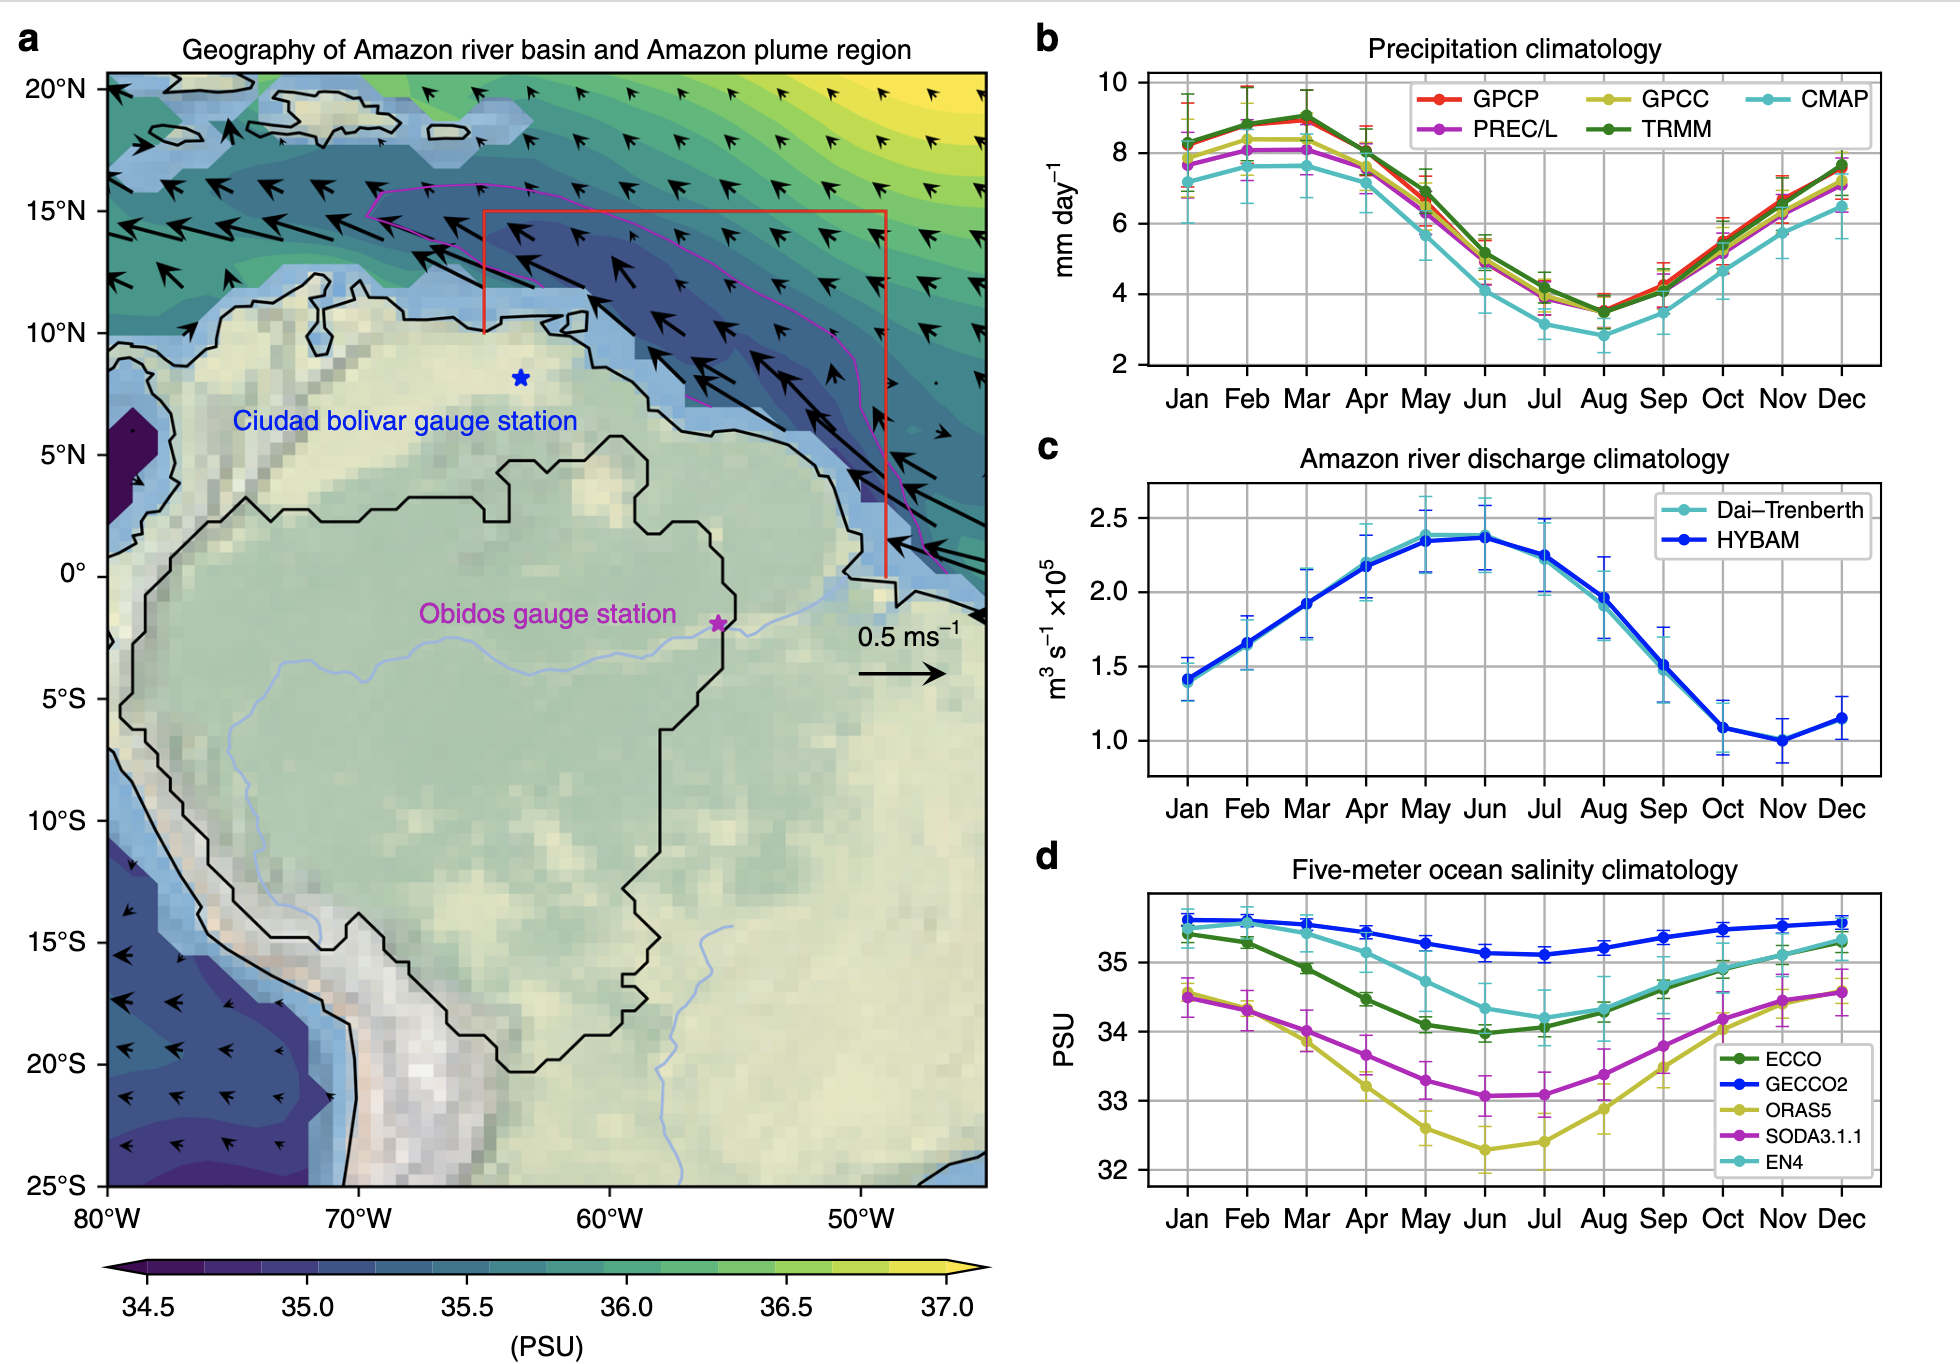

Liang et al., 

In [ ]:
# #oct-nov-dec
# seasons = ['OND','JFM','AMJ','JAS']

# fig, ax = plt.subplots(2, 2, figsize=(9, 7),
#                        subplot_kw=dict(projection=ccrs.PlateCarree()))
# ax = ax.ravel()

# for i in range(len(seasons)):
#     dd = hist_season.sel(start_season=str(seasons[i])).sum("obs")

#     np.log10(dd).plot.contourf(
#         x='lon', y='lat', ax=ax[i], transform=ccrs.PlateCarree(),
#         add_colorbar=False, cmap='Spectral_r'
#     )
#     ax[i].coastlines()
#     ax[i].set_title(seasons[i], fontsize=12)
#     ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
#     ax[i].set_xticks(np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
#     ax[i].set_yticks(np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
#     ax[i].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
#     ax[i].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
#     ax[i].tick_params(labelsize=9)
#     ax[i].set_ylabel('')
#     ax[i].set_xlabel('')

# fig.subplots_adjust(wspace=0.2, hspace=-0.65)
# plt.tight_layout()
# # plt.savefig("seasonality_subplots_45678.png", dpi=300, bbox_inches="tight")
# plt.show()

### Hist Mesoescale

In [ ]:
import math
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

In [ ]:
hist_5 = xr.open_dataset("_hist_AT_N_seminar_3.nc").compute().histogram_lon_lat
print(hist_5)

In [ ]:
# for i in range(len(hist_5.start_time)):
for i in range(0,4): 
    
    dat = hist_5.isel(start_time=i).sum("obs")
    
    fig, ax = plt.subplots(1, 1, figsize=(10,20), subplot_kw=dict(projection=ccrs.PlateCarree()))
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax,
                    add_colorbar=False,colors='#000080',alpha = 0.5, levels=[0,hist_5.max()]
                )
    ax.coastlines()

In [ ]:
da = hist_5.sum("obs")                 # (start_time, lon, lat)
dlog = da.where(da > 0).map_blocks(np.log10)

n = dlog.sizes["start_time"]           # 260
cols = 4
rows = math.ceil(n / cols)             # 65

# common color scale
vmin = float(np.nanmin(dlog.values))
vmax = float(np.nanmax(dlog.values))

fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 2.8*rows),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = np.asarray(axes).ravel()

fig.tight_layout(pad=0.1)
fig.subplots_adjust(wspace=0.2, hspace=-0.98)

for i in range(n):
    ax = axes[i]
    slc = dlog.isel(start_time=i)
    im = slc.plot.contourf(
        x="lon", y="lat", ax=ax, transform=ccrs.PlateCarree(),
        levels=20, vmin=vmin, vmax=vmax, cmap="Spectral_r", add_colorbar=False
    )
    # ax.set_title(np.datetime_as_string(slc.start_time.item(), unit='D'), fontsize=7)
    ax.coastlines(resolution='110m', linewidth=0.3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax.add_feature(cf.BORDERS, linewidth=0.3)

# remove any unused axes (none expected here)
for j in range(n, rows*cols):
    fig.delaxes(axes[j])

# shared colorbar
# cbar = fig.colorbar(im, ax=axes[:n], orientation='vertical',
#                     fraction=0.02, pad=0.01, aspect=40)
# cbar.set_label('log10(count)')
# plt.tight_layout()
plt.savefig("Mesoescale_3.pdf")  # dpi not needed
plt.show()

In [ ]:
da = hist_5.sum("obs")                 # (start_time, lon, lat)
dlog = da.where(da > 0).map_blocks(np.log10)

n = dlog.sizes["start_time"]           # 260
cols = 4
rows = math.ceil(n / cols)             # 65

fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 2.8*rows),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = np.asarray(axes).ravel()

fig.tight_layout(pad=0.1)
fig.subplots_adjust(wspace=0.3, hspace=-0.95)

for i in range(n):
    ax = axes[i]
    slc = dlog.isel(start_time=i)
    im = slc.plot.contourf(
        x="lon", y="lat", ax=ax, transform=ccrs.PlateCarree(),
        colors='#000080',alpha = 0.5, levels=[0,hist_5.max()], add_colorbar=False
    )
    # ax.set_title(np.datetime_as_string(slc.start_time.item(), unit='D'), fontsize=7)
    ax.coastlines(resolution='110m', linewidth=0.3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax.add_feature(cf.BORDERS, linewidth=0.3)

# remove any unused axes (none expected here)
for j in range(n, rows*cols):
    fig.delaxes(axes[j])

# shared colorbar
# cbar = fig.colorbar(im, ax=axes[:n], orientation='vertical',
#                     fraction=0.02, pad=0.01, aspect=40)
# cbar.set_label('log10(count)')
plt.tight_layout()
# plt.savefig("Mesoescale_3.pdf")  # dpi not needed
plt.show()

In [ ]:
ssh5 = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/ssh_cs.nc')
ssh5 = ssh5.compute()
ssh5

In [ ]:
sal5 = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/sal5.nc')
sal5 = sal5.compute()
sal5

In [ ]:
lon = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).longitude.values  # replace with your lon 1D
lat = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).latitude.values   # replace with your lat 1D

lon_sal = sal5['longitude'].values
lat_sal = sal5['latitude'].values 

## plotting
fig, ax = plt.subplots(2, 2, figsize=(9,7), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

jj=0
for i in range(130,134): 
    
    dat = hist_5.isel(start_time=i).sum("obs")
    ssh_ = ssh5.zos.isel(time=i).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).squeeze()
    sal_ = sal5.so.isel(time=i+1)
    
    U, V,x,y = ssh_stream_vectors(ssh_)


    print(ssh5.time[i].values)
    print(sal5.time[i+1].values)
    
    
    fig.set_dpi(150)
    sal_.plot.pcolormesh(robust=True,cmap='viridis_r',alpha=0.9,add_colorbar=False,ax=ax[jj])
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[jj],
                    add_colorbar=False,colors='#ff0000',alpha = 0.5, levels=[0,hist_5.max()]
                )
    strm = ax[jj].streamplot(lon, lat, U, V,
                     transform=ccrs.PlateCarree(),  # tell Cartopy the data CRS
                     color='white', density=5, arrowsize=0.2, linewidth=1)
    
    
    ax[jj].coastlines()
    ax[jj].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[jj].add_feature(cf.BORDERS)
    ax[jj].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    # ax[jj].set_xticks(np.arange(np.floor(dat.lon.min()), np.ceil(dat.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    # ax[jj].set_yticks(np.arange(np.floor(dat.lat.min()), np.ceil(dat.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    # ax[jj].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].tick_params(labelsize=9)
    ax[jj].set_ylabel('')
    ax[jj].set_xlabel('')
    jj=jj+1
fig.subplots_adjust(wspace=0.2, hspace=-0.65)
plt.tight_layout()

plt.show()

In [ ]:
sal10 = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/sal10.nc')
sal10 = sal10.compute()
# sal10

In [ ]:
ssh10 = ssh5.resample(time="10D").mean()
ssh10

In [ ]:
lon = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).longitude.values  # replace with your lon 1D
lat = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).latitude.values   # replace with your lat 1D

lon_sal = sal5['longitude'].values
lat_sal = sal5['latitude'].values 

SC = ['2024-03-17','2024-03-27','2024-04-06','2024-04-16','2024-04-26']

## plotting
fig, ax = plt.subplots(2, 2, figsize=(9,7), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

jj=0
for i in range(130,134): 
    
    dat = hist_5.isel(start_time=i).sum("obs")
    ssh_ = ssh5.zos.sel(time=SC[jj]).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).squeeze()
    sal_ = sal5.so.sel(time=SC[jj])
    
    U, V,x,y = ssh_stream_vectors(ssh_)


    print(SC[jj])
    print(SC[jj])
    
    
    fig.set_dpi(150)
    sal_.plot.pcolormesh(robust=True,cmap='viridis_r',alpha=0.9,add_colorbar=False,ax=ax[jj])
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[jj],
                    add_colorbar=False,colors='#ff0000',alpha = 0.5, levels=[0,hist_5.max()]
                )
    strm = ax[jj].streamplot(lon, lat, U, V,
                     transform=ccrs.PlateCarree(),  # tell Cartopy the data CRS
                     color='white', density=5, arrowsize=0.2, linewidth=1)
    
    
    ax[jj].coastlines()
    ax[jj].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[jj].add_feature(cf.BORDERS)
    ax[jj].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    # ax[jj].set_xticks(np.arange(np.floor(dat.lon.min()), np.ceil(dat.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    # ax[jj].set_yticks(np.arange(np.floor(dat.lat.min()), np.ceil(dat.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    # ax[jj].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].tick_params(labelsize=9)
    ax[jj].set_ylabel('')
    ax[jj].set_xlabel('')
    jj=jj+1
fig.subplots_adjust(wspace=0.2, hspace=-0.65)
plt.tight_layout()

plt.show()

In [ ]:
UV5 = xr.open_dataset('/work/bk1450/b383184/Amazon/Atlantic/data/tracers/ds_uv5.nc')
UV5 = UV5.compute()
UV5

In [ ]:
lon = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).longitude.values  # replace with your lon 1D
lat = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).latitude.values   # replace with your lat 1D

## plotting
fig, ax = plt.subplots(2, 2, figsize=(9,7), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

jj=0
for i in range(130,134): 
    
    dat = hist_5.isel(start_time=i).sum("obs")
    ssh_ = ssh5.zos.isel(time=i).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).squeeze()
    uv_ = UV5.speed.isel(time=i+1)
    
    U, V,x,y = ssh_stream_vectors(ssh_)


    print(ssh5.time[i].values)
    print(sal5.time[i+1].values)
    
    
    fig.set_dpi(150)
    uv_.plot.pcolormesh(robust=True,cmap='viridis',alpha=0.9,add_colorbar=False,ax=ax[jj])
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[jj],
                    add_colorbar=False,colors='#ff0000',alpha = 0.5, levels=[0,hist_5.max()]
                )
    strm = ax[jj].streamplot(lon, lat, U, V,
                     transform=ccrs.PlateCarree(),  # tell Cartopy the data CRS
                     color='white', density=5, arrowsize=0.2, linewidth=1)
    
    
    ax[jj].coastlines()
    ax[jj].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[jj].add_feature(cf.BORDERS)
    ax[jj].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    # ax[jj].set_xticks(np.arange(np.floor(dat.lon.min()), np.ceil(dat.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    # ax[jj].set_yticks(np.arange(np.floor(dat.lat.min()), np.ceil(dat.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    # ax[jj].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].tick_params(labelsize=9)
    ax[jj].set_ylabel('')
    ax[jj].set_xlabel('')
    jj=jj+1
fig.subplots_adjust(wspace=0.2, hspace=-0.65)
plt.tight_layout()

plt.show()

In [ ]:
lon = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).longitude.values  # replace with your lon 1D
lat = ssh5.sel(longitude=slice(-65,-30),latitude=slice(-6,14)).latitude.values   # replace with your lat 1D

## plotting
fig, ax = plt.subplots(2, 2, figsize=(9,7), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax = ax.ravel()

jj=0
for i in range(130,134): 
    
    dat = hist_5.isel(start_time=i).sum("obs")
    ssh_ = ssh5.zos.isel(time=i).sel(longitude=slice(-65,-30),latitude=slice(-6,14)).squeeze()
    uv_ = UV5.vorticity.isel(time=i+1)
    
    U, V,x,y = ssh_stream_vectors(ssh_)


    print(ssh5.time[i].values)
    print(sal5.time[i+1].values)
    
    
    fig.set_dpi(150)
    uv_.plot.pcolormesh(robust=True,cmap='viridis',alpha=0.9,add_colorbar=False,ax=ax[jj])
    np.log10(dat).plot.contourf(
                    x="lon", y="lat",
                    transform=ccrs.PlateCarree(), ax=ax[jj],
                    add_colorbar=False,colors='#ff0000',alpha = 0.5, levels=[0,hist_5.max()]
                )
    strm = ax[jj].streamplot(lon, lat, U, V,
                     transform=ccrs.PlateCarree(),  # tell Cartopy the data CRS
                     color='white', density=5, arrowsize=0.2, linewidth=1)
    
    
    ax[jj].coastlines()
    ax[jj].set_extent([-85, 0, -6, 29], crs=ccrs.PlateCarree())
    ax[jj].add_feature(cf.BORDERS)
    ax[jj].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    # ax[jj].set_xticks(np.arange(np.floor(dat.lon.min()), np.ceil(dat.lon.max())+1e-6, 10), crs=ccrs.PlateCarree())
    # ax[jj].set_yticks(np.arange(np.floor(dat.lat.min()), np.ceil(dat.lat.max())+1e-6, 5), crs=ccrs.PlateCarree())
    # ax[jj].xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol='°'))
    # ax[jj].tick_params(labelsize=9)
    ax[jj].set_ylabel('')
    ax[jj].set_xlabel('')
    jj=jj+1
fig.subplots_adjust(wspace=0.2, hspace=-0.65)
plt.tight_layout()

plt.show()